# Example 1a (JAX Backend): Static Inverse Solve for MAST-U


---

This example notebook shows how to use FreeGSNKE to solve **static inverse** free-boundary Grad-Shafranov (GS) problems. 

In the **inverse** solve mode we seek to estimate the active poloidal field coil currents using user-defined constraints (e.g. on isoflux, x-point, o-point, and psi values) and plasma current density profiles for a desired equilibrium shape. 

Note that during this solve, currents are **not** found in any specified passive structures. 

Below, we illustrate how to use the solver for both diverted and limited plasma configurations in a **MAST-U-like tokamak** using stored pickle files containing the machine description. These machine description files partially come from the FreeGS repository and are not an exact replica of MAST-U.

> **Note:** This notebook uses the high-performance GPU-accelerated **JAX backend** (`freegsnke.set_backend("jax")`).


### The static free-boundary Grad-Shafranov problem

Here we will outline the **static free-boundary** GS problem that is solved within both the **forward** and **inverse** solvers, though we encourage you to see [Amorisco et al. (2024)](https://pubs.aip.org/aip/pop/article/31/4/042517/3286904/FreeGSNKE-A-Python-based-dynamic-free-boundary) and [Pentland et al. (2024)](https://arxiv.org/abs/2407.12432) for more details. 

Using a cylindrical coordinate system $(R,\phi,Z)$, the aim is to solve the GS equation:

$$ \Delta^* \psi \equiv \left( \frac{\partial^2}{\partial R^2} - \frac{1}{R} \frac{\partial}{\partial R} + \frac{\partial^2}{\partial Z^2} \right) \psi = -\mu_0 R J_{\phi}(\psi, R, Z), \qquad (R,Z) \in \Omega, $$

for the poloidal flux $\psi(R,Z)$ (which here has units Weber/$2\pi$) in the rectangular computational domain $\Omega$. The flux has contributions from both the plasma and the coils (metals) such that $\psi = \psi_p + \psi_c$. This flux defines the toroidal current density $J_{\phi} = J_p(\psi,R,Z) + J_c(R,Z)$, also containing a contribution from both the plasma and coils, respectively. We have the plasma current density (only valid in the core plasma region $\Omega_p$):

$$ J_p(\psi,R,Z) = R \frac{\mathrm{d}p}{\mathrm{d}\psi} +\frac{1}{\mu_0 R} F \frac{\mathrm{d} F}{\mathrm{d} \psi}, \qquad (R,Z) \in \Omega_p, $$

where $p(\psi)$ is the plasma pressure profile and $F(\psi)$ is the toroidal magnetic field profile. The current density generated by $N$ active coils and passive structures is given by:

$$ J_c(R,Z) = \sum_{j=1}^{N} \frac{I^c_j(R,Z)}{A_j^c}, \qquad (R,Z) \in \Omega, \quad \text{where} \quad I_j^c(R,Z) = 
\begin{cases} 
    I_j^c & \text{if } (R,Z) \in \Omega_j^c, \\ 
    0 & \text{elsewhere}.
\end{cases}.$$

This makes use of the current $I^c_j$ in each metal and its cross-sectional area $A^c_j$ (the domain of each metal is denoted by $\Omega_j^c$).

To complete the problem, we need the integral (Dirichlet) free-boundary condition:

$$ \psi(R,Z) = \int_{\Omega} G(R,Z;R',Z') J_{\phi}(\psi, R',Z') \ \mathrm{d}R' \mathrm{d}Z', \qquad (R,Z) \in \partial \Omega, $$

where $G$ is the (known) Green's function for the elliptic operator above.

We'll now go through the steps required to solve the **inverse** problem in FreeGSNKE. 

### Create the machine object

First, we build the machine object from previously created pickle files in the "machine_configs/MAST-U" directory. 

FreeGSNKE requires the following paths in order to build the machine:
- `active_coils_path`
- `passive_coils_path`
- `limiter_path`
- `wall_path`
- `magnetic_probe_path` (not required here)

In [1]:
import freegsnke
freegsnke.set_backend("jax")

# build machine
from freegsnke import build_machine
tokamak = build_machine.tokamak(
    active_coils_path="../machine_configs/MAST-U/MAST-U_like_active_coils.pickle",
    passive_coils_path="../machine_configs/MAST-U/MAST-U_like_passive_coils.pickle",
    limiter_path="../machine_configs/MAST-U/MAST-U_like_limiter.pickle",
    wall_path="../machine_configs/MAST-U/MAST-U_like_wall.pickle",
)

Active coils --> built from pickle file.
Passive structures --> built from pickle file.
Limiter --> built from pickle file.
Wall --> built from pickle file.


Magnetic probes --> none provided.


Resistance (R) and inductance (M) matrices --> built using actives (and passives if present).
Tokamak built.


Text(9.777777777777777, 0.5, 'Height, $Z$ [m]')

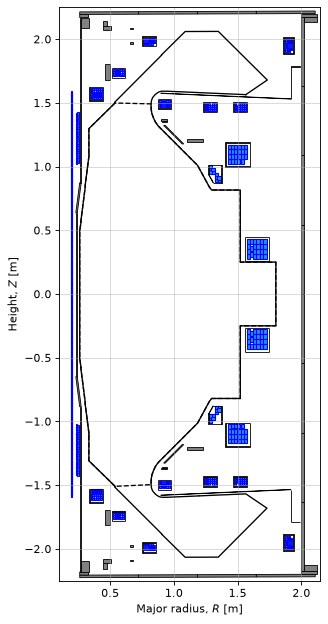

In [2]:
# plot the machine
import matplotlib.pyplot as plt

fig1, ax1 = plt.subplots(1, 1, figsize=(4, 8), dpi=80)
plt.tight_layout()

tokamak.plot(axis=ax1, show=False)
ax1.plot(tokamak.limiter.R, tokamak.limiter.Z, color='k', linewidth=1.2, linestyle="--")
ax1.plot(tokamak.wall.R, tokamak.wall.Z, color='k', linewidth=1.2, linestyle="-")

ax1.grid(alpha=0.5)
ax1.set_aspect('equal')
ax1.set_xlim(0.1, 2.15)
ax1.set_ylim(-2.25, 2.25)
ax1.set_xlabel(r'Major radius, $R$ [m]')
ax1.set_ylabel(r'Height, $Z$ [m]')

### Instantiate an equilibrium

We are now ready to build a plasma equilibrium object for our tokamak. This is done using the `freegs4e.Equilibrium` class, which implicitly defines the rectangular domain of the solver as well as the grid resolution.

`Equilibrium` has sensible defaults, but it is recommended to define the radial and vertical domain of the grid using the `Rmin`, `Rmax`, `Zmin` and `Zmax` parameters, as well as the grid resolution in the radial and vertical directions with the `nx` and `ny` parameters. The grid will be initialised using fourth-order finite differences. Note that the limiter contour **must** lie strictly inside the computational grid, because limiter-boundary flux interpolation is used when identifying limited plasmas. The grid does not need to encompass any/all of the active coils or passive structures. 

A tokamak object should be supplied to the `tokamak` parameter to assign the desired machine to the equilibrium.

If available, an initial guess for the plasma flux $\psi_p$ (dimensions `nx` x `ny`) can be provided via the `psi` parameter (commented out in the following code). If not, the default initialisation will be used.  

The `eq` object will store a lot of important information and derived quantities once the equilibrium has been calculated (see future notebook on this). 

In [3]:
from freegsnke import equilibrium_update

eq = equilibrium_update.Equilibrium(
    tokamak=tokamak,      # provide tokamak object
    Rmin=0.1, Rmax=2.0,   # radial range
    Zmin=-2.2, Zmax=2.2,  # vertical range
    nx=65,                # number of grid points in the radial direction (needs to be of the form (2**n + 1) with n being an integer)
    ny=129,               # number of grid points in the vertical direction (needs to be of the form (2**n + 1) with n being an integer)
    # psi=plasma_psi
)

### Instantiate a profile object

We can now instantiate a profile object that contains the chosen parameterisation of the toroidal plasma current density $J_p$ (i.e. on right hand side of the GS equation). We can then set the parameters for the chosen current density profiles. 

The following table indicates which parameterisations are currently available in FreeGSNKE and for which types of equilibrium simulation they currently work for:

| Name | Static | Evolutive (linear) | Evolutive (nonlinear) |
|-------|--------|------------------|---------------------|
| `ConstrainPaxisIp` | ✅ | ✅ | ✅ |
| `ConstrainBetapIp` | ✅ | ✅ | ✅ |
| `FiestaTopeol` | ✅ | ✅ | ✅ |
| `Lao85` | ✅ | ✅ | ✅ |
| `TensionSpline` | ✅ | ❌ | ❌ |
| `GeneralPprimeFFprime` | ✅ | ❌ | ❌ |

In this notebook, we will make use of the `ConstrainPaxisIp` (and `ConstrainBetapIp`) profiles (see [Jeon (2015)](https://link.springer.com/article/10.3938/jkps.67.843)). Others will be utilised in later notebooks. If there is a profile parameterisation you require that does not exist, please do create an issue.

Both `ConstrainPaxisIp` and `ConstrainBetapIp` are parameterised as follows:
 $$J_{p}(\psi, R, Z) = \lambda\big[ \beta_{0} \frac{R}{R_{0}} \left( 1-\tilde{\psi}^{\alpha_m} \right)^{\alpha_n} + (1-\beta_{0}) \frac{R_0}{R} \left( 1-\tilde{\psi}^{\alpha_m} \right)^{\alpha_n} \big] \quad (R,Z) \in \Omega_p,$$

where the first term is the pressure profile and the second is the toroidal current profile. Here, $\tilde{\psi}$ denotes the normalised flux:
$$ \tilde{\psi} = \frac{\psi - \psi_a}{\psi_b - \psi_a}, $$
where $\psi_a$ and $\psi_b$ are the values of the flux on the magnetic axis and plasma boundary, respectively. 

The parameters required to define this particular profile are:
- `Ip` (total plasma current).
- `fvac` ($R B_{tor}$, vacuum toroidal field strength).
- `alpha_m`>0, and `alpha_n`>0 (that define the shape/peakedness of the profiles).
- If `ConstrainPaxisIp` is used, then `paxis` (pressure on the magnetic axis) is required.
- If `ConstrainBetapIp` is used, then `betap` (proxy of the poloidal beta) is required.


The values of $\lambda$ and $\beta_0$ are found using the above parameters as constraints ($R_0$ is a fixed scaling constant) in the following:

- For `ConstrainPaxisIp`, we can re-arrange the following equations to solve for the unknowns:

$$ p_{\text{axis}} = \lambda \beta_{0} \frac{R}{R_{0}} \int^{\psi_b}_{\psi_a} \left( 1-\tilde{\psi}^{\alpha_m} \right)^{\alpha_n} \mathrm{d} \tilde{\psi} $$

and

$$ I_p = \int^{Z_{\text{max}}}_{Z_{\text{min}}} \int^{R_{\text{max}}}_{R_{\text{min}}} J_p(\psi, R, Z) \ \mathrm{d}R \mathrm{d}Z. $$


- For `ConstrainBetapIp`, we can instead re-arrange and solve the following:

$$ \beta_p = \frac{8 \pi}{\mu_0 I_p^2} \int^{Z_{\text{max}}}_{Z_{\text{min}}} \int^{R_{\text{max}}}_{R_{\text{min}}} p(\psi) \ \mathrm{d}R \mathrm{d}Z. $$

and

$$I_p = \int^{Z_{\text{max}}}_{Z_{\text{min}}} \int^{R_{\text{max}}}_{R_{\text{min}}} J_p(\psi, R, Z) \ \mathrm{d}R \mathrm{d}Z. $$


In what follows, we use `ConstrainPaxisIp`. Note that the equilibrium (`eq`) object is passed to the profile to inform calculations relating to the machine description.

In [4]:
# initialise the profiles
from freegsnke.jtor_update import ConstrainPaxisIp
profiles = ConstrainPaxisIp(
    eq=eq,        # equilibrium object
    paxis=8e3,    # pressure on the magnetic axis
    Ip=6e5,       # plasma current
    fvac=0.5,     # fvac = R B_{tor}
    alpha_m=1.8,  # profile function parameter
    alpha_n=1.2   # profile function parameter
)

### Load the static nonlinear solver

We can now load FreeGSNKE's static solver object. The equilibrium is used to inform the solver of the computational domain and of the tokamak properties. The solver below can be used for **both** inverse and forward solves. 

Note: It's not necessary to instantiate a new solver when aiming to use it on new or different equilibria, as long as the integration domain, mesh grid, and tokamak are consistent across solves. 

Note: A random seed can also be set here. This comes into play for tricky forward/inverse solves where the internal Newton-Krylov solver gets stuck and needs to search in random Krylov direction. See code documentation for further details.

In [5]:
from freegsnke import GSstaticsolver
GSStaticSolver = GSstaticsolver.NKGSsolver(
    eq=eq,    # eq object
    # seed=42,  # random seed
    )    

### Fixed coil currents

Firstly, we set the values for any currents in specific active poloidal field coils that we may know. The inverse solver will not allow the current in these coils to vary if the `control` parameter is set to `False` (i.e. it will be excluded during the optimisation). 

Note: any passive structures in the tokamak automatically have their control parameter set to False and are therefore not included in an inverse solve. 

As an example, we will fix the `Solenoid` current and seek a solution in which this value is fixed, rather than estimated by the inverse solve.

In [6]:
eq.tokamak.set_coil_current('Solenoid', 5000)
eq.tokamak['Solenoid'].control = False  # ensures the current in the Solenoid is fixed

### Constraints

Recall that in the **inverse** solve mode we seek to **estimate the active poloidal field coil currents** using user-defined **constraints** (e.g. on isoflux, null points, and $\psi$ values) together with prescribed plasma current density profiles, in order to obtain a desired equilibrium shape.

FreeGSNKE uses a `constrain` object, which accepts the following types of constraints:

- **Null points (`null_points`)**  
  A null point $(R_X, Z_X)$ (X-point or O-point) is defined by vanishing poloidal field, i.e. we can impose
  $$
  \nabla \psi(R_X, Z_X) = \mathbf{0}.
  $$
  In particular, an X-point is a saddle point of $\psi$ while an O-point (magnetic axis) is a local extremum (typically a minimum) of $\psi$. 
  The above is equivalent to both:
  $$
  \frac{\partial \psi}{\partial R}(R_X, Z_X) = \frac{\partial \psi}{\partial Z}(R_X, Z_X) = 0,
  $$
  or
  $$
  B_r (R_X, Z_X) = B_z(R_X, Z_X) = 0.
  $$
  This means that for each null point considered, two constraints are imposed internally within the inverse solver. 
  

- **Isoflux sets (`isoflux_set`)**  
  An isoflux set is a set of points $\{(R_i, Z_i)\}_{i=1}^k$ that lie on the same flux surface, i.e. we can impose
  $$
  \psi(R_1, Z_1) = \psi(R_2, Z_2) = \cdots = \psi(R_k, Z_k).
  $$
  Internally, the inverse solver enforces each constraint such that
  $$
  \psi(R_i, Z_i) - \psi(R_j, Z_j) = 0,
  \qquad i \neq j,
  $$
  meaning that for $k$ points in an isoflux set, there are $k(k-1)/2$ constraints. 

- **Coil current limits (`coil_current_limits`)**  
  If we wnt to enforce bounds on the coil currents (for machine safety purposes), we can impose
  $$
  I_m^{\min} \le I_m \le I_m^{\max},
  \qquad m = 1, \dots, N.
  $$

**Note**: see the next notebooks for some more advanced constraints!

At least one constraint (preferably more) is required to carry out an inverse solve. Although it may be tempting to utilise all of the above constraints, one must be careful not to **overconstrain** the inverse problem, else constraints will fight one another and the solver will not converge to an equilibrium. 

In the following, we start simple and specify two X-point locations (to obtain a double-null plasma), a few isoflux locations, and some coil current limits. The isoflux constraints define the core plasma boundary and part of the divertor legs.

In [7]:
import numpy as np 
from freegsnke.inverse import Inverse_optimizer

Rx = 0.6      # X-point radius
Zx = 1.1      # X-point height
Rout = 1.4    # outboard midplane radius
Rin = 0.34    # inboard midplane radius

# set desired null_points locations (this can include X-point and O-point locations)
null_points = [[Rx, Rx], [Zx, -Zx]]

# set desired isoflux constraints with format 
# isoflux_set = [isoflux_0, isoflux_1 ... ] 
# with each isoflux_i = [R_coords, Z_coords]
isoflux_set = np.array([
    [[Rx, Rx, Rin, Rout, 1.0, 1.0, .8,.8], [Zx, -Zx, 0.,0., 2.0, -2.0, 1.62, -1.62]]
    ])

# set the coil current limits (upper and lower)
# coil ordering in this case: PX,  D1,  D2,  D3,  Dp,  D5,  D6,  D7,  P4,  P5,  P6
coil_current_limits = [
    [5e3, 9e3, 9e3, 7e3, 7e3, 5e3, 4e3, 5e3, 0.0, 0.0, None],
    [-5e3, -9e3, -9e3, -7e3, -7e3, -5e3, -4e3, -5e3, -10e3, -10e3, None]
]
           
# instantiate the freegsnke constrain object
constrain = Inverse_optimizer(
    null_points=null_points,
    isoflux_set=isoflux_set,
    coil_current_limits=coil_current_limits
)

# if you find coil limits are being violated or an undesireable solution is being produced,
# you can try increasing the penalty factor for violating the coil limits
# (here we just set it to its default value of 1e5)
constrain.mu_coils = 1e5

### The linear system of constraints

During an inverse solve, a minimisation problem involving the responses, changes in coil currents, and constraints, is repeatedly solved:

$$ \min_{x} \| A\vec{x} - \vec{b}\|^2 + \| \gamma \vec{x} \|^2, $$

where
- $A$ is the fixed response matrix (that determines how a change in coil currents $x$, affects constraint values). 
- $\vec{x} = \Delta \vec{I}^c$ is the step change in active coil currents required to match the constraints. 
- $\vec{b}$ is the vector of constraint values being enforced. 
- $\gamma > 0$ is the regularisation parameter/vector.

We solve for $\vec{x}$ using a gradient-based optimiser. 

[Song et al. (2024)](https://www.mdpi.com/2571-6182/7/4/45) provide a nice overview of the inverse problem.

The coil limits are handled in a slightly different manner because they are box constraints that cannot be encoded in the minimisation problem. Instead, FreeGSNKE adds additional constraints to the solver that bound the solution $\Delta \vec{I}^c$. These bounds have a tolerance (slack) which allows the coils to violate their limits, but penalises violations; this allows the coil limits to be violated 'on the path' to a solution that respects the prescribed limits.


### The inverse solve

The following cell will execute the solve. Since a `constrain` object is provided, this is interpreted as a call to the inverse solver, if `constrain=None`, then the forward solver will be called (see next notebook). 

The `target_relative_tolerance` is the maximum relative error on the plasma flux function allowed for convergence and `target_relative_psit_update` ensures that the relative update to the plasma flux (caused by the update in the control currents) is lower than this target value. Both are required to be met for the inverse problem to be considered successfully solved.

The `verbose=True` option will provide an indication of the progression of the solve. 

The `l2_reg` parameter defines the Tikhonov regularisation (i.e. $\gamma$ in the cell above) used by the optimiser. This can be set as a scalar or as a vector (equal to the number of coil currents being solved for). Larger values force coil currents to stay closer to their original values while lower values will encourage more freedom. This can be useful in particular for vertical control coils (e.g. the P6 coil in MAST-U), in which we don't want the coil current to "jump around" during optimisation and cause vertical instability issues. 


The solver steps are (roughly):
1. Solve the linear system to find initial coil currents that approximately satisfy the constraints for the initial equilibrium. 
2. While tolerance is not met:
    - use the coil currents to solve the forward GS problem (with Newton-Krylov iterations).
    - solve the linear system to update coil currents to satisfy constraints for current equilibrium (from forward solve). 
    - check tolerances. 

Given that there may be more or less constraints than unknown parameters (i.e. coil currents), the inverse problem may be over- or under-constrained. This means that there may be zero, one, or many solutions to the problem. It is often a bit of an art when solving inverse problems so the best strategy is to start with some basic isoflux constraints before trying to add null points and others.

In [8]:
# solve!
GSStaticSolver.solve(eq=eq, 
                     profiles=profiles, 
                     constrain=constrain, 
                     target_relative_tolerance=1e-6,
                     target_relative_psit_update=1e-3,
                     verbose=True, # print output
                     l2_reg=np.array([1e-12]*10+[1e-6]), 
                     )

-----
Inverse static solve starting...


Successfully computed GS residual using initial plasma_psi and tokamak_psi guesses.
Initial relative error = 1.00e+00
-----
Iteration: 0
Using simplified Green's Jacobian (of constraints wrt coil currents) to optimise the currents.
Change in coil currents (being controlled): ['-7.66e+02', '3.01e+04', '1.51e+04', '1.98e+04', '-9.06e+03', '8.18e+03', '-1.02e+04', '-1.04e+04', '-2.63e+04', '6.08e+03', '-3.17e-10']
Constraint losses = 7.05e-01
Relative update of tokamak psi (in plasma core): 2.49e+01
Handing off to forward solve (with updated currents).
Relative error =  9.31e-01
-----
Iteration: 1
Using simplified Green's Jacobian (of constraints wrt coil currents) to optimise the currents.
Change in coil currents (being controlled): ['1.91e+03', '-7.46e+03', '-2.48e+03', '-5.86e+03', '1.76e+03', '-1.27e+03', '3.30e+03', '2.69e+03', '7.32e+03', '-2.99e+03', '-1.71e-11']
Constraint losses = 1.62e-01
Relative update of tokamak psi (in plasma core): 2.66e-02
Handing off to forward solve (wit

Change in coil currents (being controlled): ['1.40e+03', '-5.45e+03', '-2.30e+03', '-4.19e+03', '1.59e+03', '-8.16e+02', '2.21e+03', '1.89e+03', '5.25e+03', '-2.21e+03', '4.28e-10']
Constraint losses = 1.14e-01
Relative update of tokamak psi (in plasma core): 2.67e-02
Handing off to forward solve (with updated currents).
Relative error =  7.77e-01
-----
Iteration: 3
Using simplified Green's Jacobian (of constraints wrt coil currents) to optimise the currents.
Change in coil currents (being controlled): ['1.05e+03', '-4.26e+03', '-1.26e+03', '-3.31e+03', '5.19e+02', '-9.54e+02', '4.18e+03', '6.37e+02', '2.75e+03', '-1.44e+03', '6.97e-10']
Constraint losses = 7.97e-02
Relative update of tokamak psi (in plasma core): 2.47e-02
Handing off to forward solve (with updated currents).
Relative error =  6.52e-01
-----
Iteration: 4
Using simplified Green's Jacobian (of constraints wrt coil currents) to optimise the currents.
Change in coil currents (being controlled): ['1.06e+03', '-3.28e+03', '-

Relative error =  4.79e-01
-----
Iteration: 5
Using simplified Green's Jacobian (of constraints wrt coil currents) to optimise the currents.
Change in coil currents (being controlled): ['2.20e+02', '-1.70e+03', '-9.20e+02', '-3.61e+02', '5.89e+02', '-2.50e+03', '-7.34e+02', '2.03e+03', '3.38e+03', '-1.04e+03', '4.27e-10']
Constraint losses = 4.05e-02
Relative update of tokamak psi (in plasma core): 2.33e-02
Handing off to forward solve (with updated currents).
Relative error =  2.46e-01
-----
Iteration: 6
Using simplified Green's Jacobian (of constraints wrt coil currents) to optimise the currents.
Change in coil currents (being controlled): ['-1.49e+02', '-1.01e+03', '-3.68e+02', '-1.30e+02', '2.97e+02', '-1.90e+03', '-9.16e+02', '1.31e+03', '2.91e+03', '-8.80e+02', '2.85e-10']
Constraint losses = 2.84e-02
Relative update of tokamak psi (in plasma core): 1.93e-02
Handing off to forward solve (with updated currents).
Relative error =  3.83e-02
-----
Iteration: 7
Using simplified Green'

Change in coil currents (being controlled): ['-4.00e+02', '-5.12e+02', '-3.18e+02', '-6.33e+02', '1.58e+02', '-1.55e+02', '3.20e+02', '2.24e+02', '6.05e+02', '-4.73e+02', '-3.96e-15']
Constraint losses = 1.54e-02
Relative update of tokamak psi (in plasma core): 9.82e-03
Handing off to forward solve (with updated currents).


...

 - calculating derivatives for coil 8/11


 - calculating derivatives for coil 9/11


 - calculating derivatives for coil 10/11


 - calculating derivatives for coil 11/11
Change in coil currents (being controlled): ['-7.63e-01', '-1.35e-01', '3.01e-01', '6.73e-01', '1.48e+00', '9.42e-02', '1.09e+00', '5.67e-01', '1.43e-01', '-4.89e+00', '-3.35e-06']
Constraint losses = 2.11e-03
Relative update of tokamak psi (in plasma core): 2.57e-04
Handing off to forward solve (with updated currents).


Relative error =  7.77e-07
-----
Inverse static solve SUCCESS. Tolerance 7.77e-07 (vs. requested 1e-06) reached in 12/100 iterations.


The following plots show how to display:
1. the tokamak with:
   - active coil filaments (rectangles with blue interior)
   - passive structures (blue circles if defined as filaments or thin black outline/grey interior if defined as parallelograms)
   - limiter/wall (solid black)
2. the tokamak + the equilibrium with:
   - separatrix/last closed flux surface (solid red lines)
   - poloidal flux (yellow/green/blue contours, colours indicates magnitude)
   - X-points (red circles)
   - O-points (green crosses)
3. the tokamak + the equilibrium + the constraints with:
   - null-point constraints (purple Y-shaped crosses)
   - isoflux contour constraints (usual crosses)

Note: Setting 'show=True' can toggle the legend on/off.

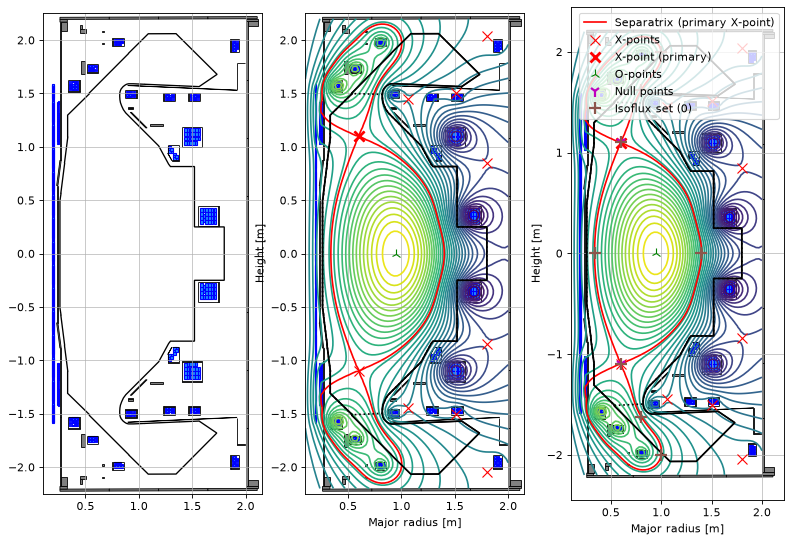

<Figure size 640x480 with 0 Axes>

In [9]:
fig1, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 8), dpi=80)

ax1.grid(zorder=0, alpha=0.75)
ax1.set_aspect('equal')
eq.tokamak.plot(axis=ax1,show=False)                                                          # plots the active coils and passive structures
ax1.fill(tokamak.wall.R, tokamak.wall.Z, color='k', linewidth=1.2, facecolor='w', zorder=0)   # plots the limiter
ax1.set_xlim(0.1, 2.15)
ax1.set_ylim(-2.25, 2.25)

ax2.grid(zorder=0, alpha=0.75)
ax2.set_aspect('equal')
eq.tokamak.plot(axis=ax2,show=False)                                                          # plots the active coils and passive structures
ax2.fill(tokamak.wall.R, tokamak.wall.Z, color='k', linewidth=1.2, facecolor='w', zorder=0)   # plots the limiter
eq.plot(axis=ax2,show=False)                                                                  # plots the equilibrium
ax2.set_xlim(0.1, 2.15)
ax2.set_ylim(-2.25, 2.25)


ax3.grid(zorder=0, alpha=0.75)
ax3.set_aspect('equal')
eq.tokamak.plot(axis=ax3,show=False)                                                          # plots the active coils and passive structures
ax3.fill(tokamak.wall.R, tokamak.wall.Z, color='k', linewidth=1.2, facecolor='w', zorder=0)   # plots the limiter
eq.plot(axis=ax3,show=False)                                                                  # plots the equilibrium
constrain.plot(axis=ax3, show=True)                                                          # plots the constraints
ax3.set_xlim(0.1, 2.15)
ax3.set_ylim(-2.25, 2.25)

plt.tight_layout()

A solve call will modify the equilibrium object in place. That means that certain quantities within the object will be updated as a result of the solve. 

Various different quantities and functions can be accessed via the 'eq' and 'profile' objects. For example:
- the total flux can be accessed with `eq.psi()`.
- the plasma flux with `eq.plasma_psi`.
- the active coil + passive structure flux with `eq.tokamak_psi`.
- (Total flux = plasma flux + coil flux)

Explore `eq.` to see more (also `profiles.`, e.g. the plasma current distribution over the domain can be found with `profiles.jtor`). Also see the `example3` notebook for how to access many different equilibrium-derived quantities of interest. 

The set of optimised coil currents can be retrieved using `eq.tokamak.getCurrents()` having been assigned to the equilibrium object during the inverse solve.

The following lines will save the calculated currents to a pickle file (we will use these in future notebooks). 

In [10]:
inverse_currents = eq.tokamak.getCurrents()
inverse_currents_arr = eq.tokamak.getCurrentsVec()[0:12]

# save coil currents to file
import pickle
with open('data/simple_diverted_currents_PaxisIp.pk', 'wb') as f:
    pickle.dump(obj=inverse_currents, file=f)

Finally, we can check that the currents we have found respect the coil limits that we prescribed earlier:


In [11]:
# storage
coil_names = []
active_currents = []
min_limits = []
max_limits = []

for coil_name, coil_current, ul, ll in zip(
    eq.tokamak.coils_dict,
    eq.tokamak.getCurrentsVec()[:12],
    [None] + coil_current_limits[0],   # upper limits
    [None] + coil_current_limits[1],   # lower limits
):
    # skip solenoid (no limits)
    if ul is None or ll is None:
        continue

    coil_names.append(coil_name)
    active_currents.append(coil_current)
    min_limits.append(ll)
    max_limits.append(ul)
    
    if (coil_current >= ll) & (coil_current <= ul):
        within_limit = True
    else:
        within_limit = False

    # print
    print(f"{coil_name}: {coil_current:.2f} --> [{ll},{ul}] [A] --> limits met = {within_limit}")

# convert to numpy
active_currents = np.array(active_currents)
min_limits = np.array(min_limits)
max_limits = np.array(max_limits)

PX: 3696.81 --> [-5000.0,5000.0] [A] --> limits met = True
D1: 6941.24 --> [-9000.0,9000.0] [A] --> limits met = True
D2: 4390.86 --> [-9000.0,9000.0] [A] --> limits met = True
D3: 2924.36 --> [-7000.0,7000.0] [A] --> limits met = True
Dp: -2488.20 --> [-7000.0,7000.0] [A] --> limits met = True
D5: 249.19 --> [-5000.0,5000.0] [A] --> limits met = True
D6: -314.99 --> [-4000.0,4000.0] [A] --> limits met = True
D7: 511.08 --> [-5000.0,5000.0] [A] --> limits met = True
P4: -3564.38 --> [-10000.0,0.0] [A] --> limits met = True
P5: -3954.23 --> [-10000.0,0.0] [A] --> limits met = True


We can also visualise the currents with respect to their limits (normalising between -1 and 1). Note the Solenoid and P6 are missing as they have no limits in this case. 

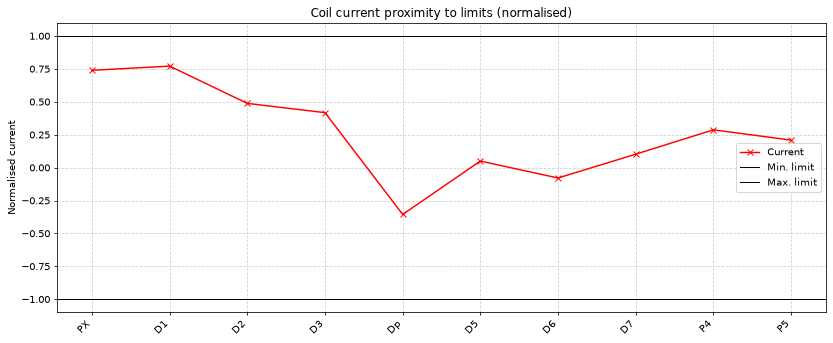

In [12]:
# VISUALISE HOW CLOSE THEY ARE TO THE LIMITS (normalised)

# normalized to [-1, 1] scale (relative to min/max)
norm_current = 2 * (active_currents - min_limits) / (max_limits - min_limits) - 1

# plot
plt.figure(figsize=(12, 5), dpi=70)
x = np.arange(len(coil_names))

# line plot
plt.plot(x, norm_current, marker='x', linestyle='-', color='red', label="Current")
plt.axhline(-1, color='k', linestyle='-', linewidth=1, label="Min. limit")
plt.axhline(1, color='k', linestyle='-', linewidth=1, label="Max. limit")

# formatting
plt.xticks(x, coil_names, rotation=45, ha='right')
plt.ylabel('Coil name [Amps]')
plt.ylabel('Normalised current')
plt.title('Coil current proximity to limits (normalised)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


### Second inverse solve: limited plasma example

Below we carry out an inverse solve seeking coil current values for a limited plasma configuration (rather than a diverted one). 

In a limiter configuration the plasma "touches" the limiter of the tokamak and is confined by the solid structures of the vessel. The last closed flux surface (LCFS) is the closed contour that is furthest from the magnetic axis that just barely touches (and is tangent to) the limiter.

In [13]:
# a new eq object resets the coil currents and equilibrium
eq = equilibrium_update.Equilibrium(
    tokamak=tokamak,      # provide tokamak object
    Rmin=0.1, Rmax=2.0,   # radial range
    Zmin=-2.2, Zmax=2.2,  # vertical range
    nx=65,                # number of grid points in the radial direction (needs to be of the form (2**n + 1) with n being an integer)
    ny=129,               # number of grid points in the vertical direction (needs to be of the form (2**n + 1) with n being an integer)
)

# initialise the profiles
profiles = ConstrainPaxisIp(
    eq=eq,        # equilibrium object
    paxis=6e3,    # pressure on the magnetic axis  <-- changed
    Ip=4e5,       # plasma current                 <-- changed
    fvac=0.5,     # fvac = R B_{tor}
    alpha_m=1.8,  # profile function parameter
    alpha_n=1.2   # profile function parameter
)

# first we specify some alternative constraints
Rout = 1.4    # outboard midplane radius
Rin = 0.255   # inboard midplane radius (less than the wall radius to make it limited)

# locations of X-points
Rx = 0.45
Zx = 1.18
null_points = [[Rx, Rx], [Zx, -Zx]]

# isoflux constraints
isoflux_set = [
    [Rx, Rx, Rout, Rin, Rin, Rin, Rin, Rin, .75, .75, .85, .85],
    [Zx, -Zx,  0,  0,  .1, -.1, .2, -.2, 1.6, -1.6, 1.7, -1.7]
    ]

# let's assume we're seeking an equilibrium with no solenoid current
eq.tokamak.set_coil_current('Solenoid', 0)
eq.tokamak['Solenoid'].control = False # fixes the current

# also make it perfectly up/down symmetric (as P6 is wired in anti-series vs. the other coils)
eq.tokamak.set_coil_current('P6', 0)
eq.tokamak['P6'].control = False # fixes the current

# pass the magnetic constraints to a new constrain object
constrain = Inverse_optimizer(
    null_points=null_points,
    isoflux_set=isoflux_set
    )

# carry out the solve
GSStaticSolver.solve(eq=eq, 
                     profiles=profiles, 
                     constrain=constrain, 
                     target_relative_tolerance=1e-6,
                     target_relative_psit_update=1e-3,
                     verbose=True, # print output
                     l2_reg=np.array([1e-9]*10),
                     )

-----
Inverse static solve starting...


Successfully computed GS residual using initial plasma_psi and tokamak_psi guesses.
Initial relative error = 9.73e-01
-----
Iteration: 0
Using simplified Green's Jacobian (of constraints wrt coil currents) to optimise the currents.
Change in coil currents (being controlled): ['1.04e+04', '1.80e+02', '1.99e+04', '4.19e+04', '-1.14e+04', '3.17e+03', '-1.98e+04', '-1.57e+04', '-3.84e+04', '1.83e+04']
Constraint losses = 8.36e-01
Relative update of tokamak psi (in plasma core): 1.43e+00
Handing off to forward solve (with updated currents).
Relative error =  9.53e-01
-----
Iteration: 1
Using simplified Green's Jacobian (of constraints wrt coil currents) to optimise the currents.
Change in coil currents (being controlled): ['-3.55e+03', '-2.11e+03', '-6.36e+03', '-1.33e+04', '3.55e+03', '-9.29e+02', '6.18e+03', '5.02e+03', '1.25e+04', '-5.01e+03']
Constraint losses = 2.80e-01
Relative update of tokamak psi (in plasma core): 1.90e-02
Handing off to forward solve (with updated currents).
Relat

Relative error =  4.91e-01
-----
Iteration: 6
Using simplified Green's Jacobian (of constraints wrt coil currents) to optimise the currents.
Change in coil currents (being controlled): ['-8.03e+02', '-3.77e+02', '-1.18e+03', '-2.44e+03', '6.32e+02', '-1.87e+02', '1.14e+03', '9.16e+02', '2.28e+03', '-1.12e+03']
Constraint losses = 4.74e-02
Relative update of tokamak psi (in plasma core): 2.67e-02
Handing off to forward solve (with updated currents).
Relative error =  2.80e-01
-----
Iteration: 7
Using simplified Green's Jacobian (of constraints wrt coil currents) to optimise the currents.
Change in coil currents (being controlled): ['-6.69e+02', '-2.45e+02', '-7.98e+02', '-1.63e+03', '4.12e+02', '-1.34e+02', '7.60e+02', '6.05e+02', '1.51e+03', '-8.32e+02']
Constraint losses = 3.15e-02
Relative update of tokamak psi (in plasma core): 2.23e-02
Handing off to forward solve (with updated currents).
Relative error =  6.90e-02
-----
Iteration: 8
Using simplified Green's Jacobian (of constraint

Relative error =  2.28e-02
-----
Iteration: 9
Using simplified Green's Jacobian (of constraints wrt coil currents) to optimise the currents.
Change in coil currents (being controlled): ['-2.54e+01', '-3.59e+00', '1.23e+00', '-1.36e-01', '8.77e+00', '-2.17e+01', '-7.62e+00', '-1.81e+01', '-3.21e+01', '-1.31e+02']
Constraint losses = 1.08e-01
Relative update of tokamak psi (in plasma core): 2.13e-02
Handing off to forward solve (with updated currents).


Relative error =  1.99e-03
-----
Iteration: 10
Using simplified Green's Jacobian (of constraints wrt coil currents) to optimise the currents.
Change in coil currents (being controlled): ['-5.45e+01', '-9.65e+00', '-3.09e+00', '-6.38e+00', '1.59e+01', '-2.60e+01', '-2.91e+00', '-1.73e+01', '-3.06e+01', '-1.69e+02']
Constraint losses = 5.29e-02
Relative update of tokamak psi (in plasma core): 2.05e-02
Handing off to forward solve (with updated currents).
Relative error =  5.00e-05
-----
Iteration: 11
Using simplified Green's Jacobian (of constraints wrt coil currents) to optimise the currents.
Change in coil currents (being controlled): ['-1.22e+02', '-3.61e+01', '-3.79e+01', '-4.68e+01', '1.02e+01', '2.26e+01', '4.11e+01', '4.44e+01', '8.56e+01', '9.53e+01']
Constraint losses = 1.91e-02
Relative update of tokamak psi (in plasma core): 1.30e-02
Handing off to forward solve (with updated currents).


...

 - calculating derivatives for coil 5/10
 - calculating derivatives for coil 6/10


 - calculating derivatives for coil 7/10
 - calculating derivatives for coil 8/10


 - calculating derivatives for coil 9/10


 - calculating derivatives for coil 10/10
Change in coil currents (being controlled): ['-5.76e-01', '4.30e-01', '-2.11e-01', '-5.82e-01', '6.87e-01', '9.27e-01', '1.34e+00', '1.44e+00', '2.57e+00', '2.61e+00']
Constraint losses = 2.57e-03
Relative update of tokamak psi (in plasma core): 4.53e-04
Handing off to forward solve (with updated currents).


Relative error =  7.45e-07
-----
Inverse static solve SUCCESS. Tolerance 7.45e-07 (vs. requested 1e-06) reached in 34/100 iterations.


In [14]:
# save the currents for later use
inverse_current_values = eq.tokamak.getCurrents()

# save coil currents to file
with open('data/simple_limited_currents_PaxisIp.pk', 'wb') as f:
    pickle.dump(obj=inverse_current_values, file=f)

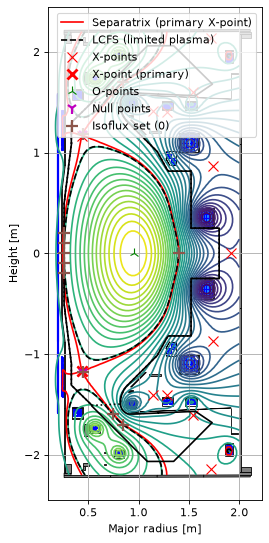

<Figure size 640x480 with 0 Axes>

In [15]:
# plot the resulting equilibria 
fig1, ax1 = plt.subplots(1, 1, figsize=(4, 8), dpi=80)
ax1.grid(True, which='both')
eq.plot(axis=ax1, show=False)
eq.tokamak.plot(axis=ax1, show=False)
constrain.plot(axis=ax1,show=True)
ax1.set_xlim(0.1, 2.15)
ax1.set_ylim(-2.25, 2.25)
plt.tight_layout()